In [2]:
import pandas as pd 
#Légende : 
#Date : Date de la journée de trading
#Open : prix d'ouverture
#High : prix le plus haut de la journée
#Low : prix le plus bas de la journée
#Close : prix de clôture
#Adj Close : prix de clôture ajusté (ajusté pour les dividendes et les fractionnements d'actions)
#Volume : nombre d'actions échangées pendant la journée

stocks_data=pd.read_csv('AAPL_1981_2023.csv')
print(stocks_data.head())
stocks_data_missing_values=stocks_data.isnull().sum()>0

if(stocks_data_missing_values.any()):
    print("-------------------------------")
    print(stocks_data.isnan().sum())
    print("Il y a des valeurs manquantes dans les données.")
else:
    print("il n'ya pas de valeur manquante dans ce dataset")

#les types de données de chaque data 
stocks_data_columns=stocks_data.columns
for column in stocks_data_columns:
    print("-------------------------------")
    print(f"Le type de données de la colonne '{column}' est : {stocks_data[column].dtype}")


#statistique descriptive 
print("-------------------------------")
print("statistique descriptive :")
print(stocks_data.describe())

print("-------------------------------")
print("Information sur le dataset :")
print(stocks_data.info())

         Date      Open      High       Low     Close  Adj Close    Volume
0  02/01/1981  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1  05/01/1981  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
2  06/01/1981  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
3  07/01/1981  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
4  08/01/1981  0.135603  0.135603  0.135045  0.135045   0.105085  39827200
il n'ya pas de valeur manquante dans ce dataset
-------------------------------
Le type de données de la colonne 'Date' est : str
-------------------------------
Le type de données de la colonne 'Open' est : float64
-------------------------------
Le type de données de la colonne 'High' est : float64
-------------------------------
Le type de données de la colonne 'Low' est : float64
-------------------------------
Le type de données de la colonne 'Close' est : float64
-------------------------------
Le type de données de la colonne 'Adj Close'

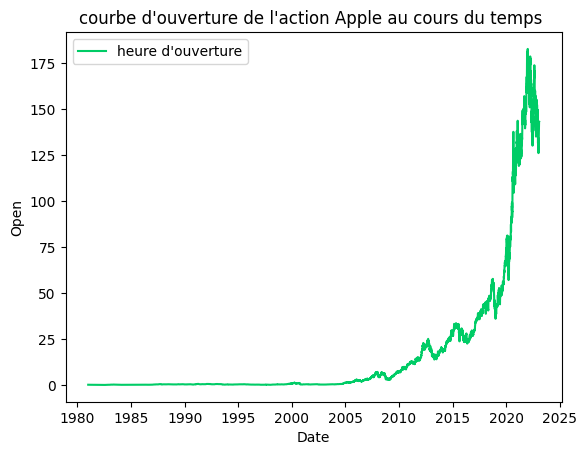

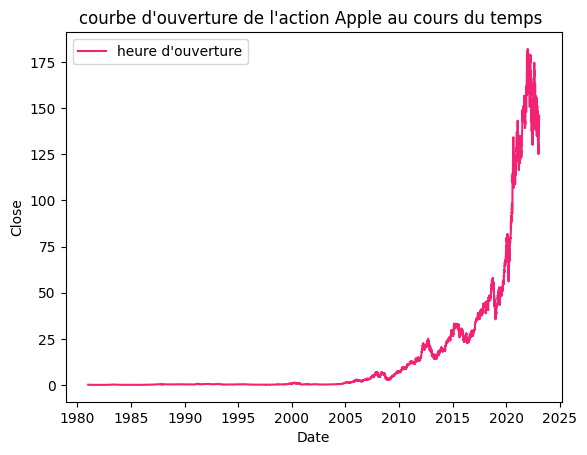

In [ ]:

#Il n'ya pas de valeur manquante dans ce dataset , on peut donc passer à l'analyse des données  et à al visualisation
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd # N'oublie pas d'importer pandas si ce n'est pas fait plus haut

# Convertir la colonne 'Date' en format Date 
stocks_data['Date'] = pd.to_datetime(stocks_data['Date'], format="%d/%m/%Y")


def Show_linear_graph(dataset, x_variable, y_variable, color="#00CC66"):
    plt.title("courbe d'ouverture de l'action Apple au cours du temps ")
    sns.lineplot(data=dataset, x=x_variable, y=y_variable, label='heure d\'ouverture', color=color)
    plt.show()

data_chunk = stocks_data.head(100) #pour bien visualiser à une plus petite échelle


# Appels de la fonction qui permet d'afficher les courbes 
Show_linear_graph(stocks_data, 'Date', 'Open') # Courbe d'ouverture
Show_linear_graph(stocks_data, 'Date', 'Close', color="#F42272") # Courbe de clôture




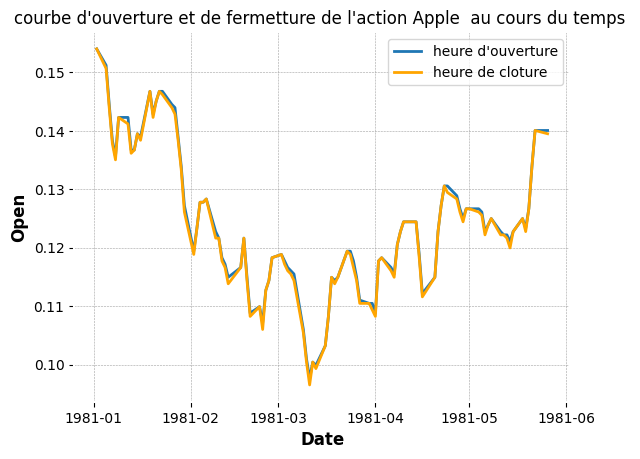

c:\Users\Hp\Documents\FORMATION FORPRODE GENAI & MACHINE LEARNING 2026\FORPRODE_genAI_bootcamp\env\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


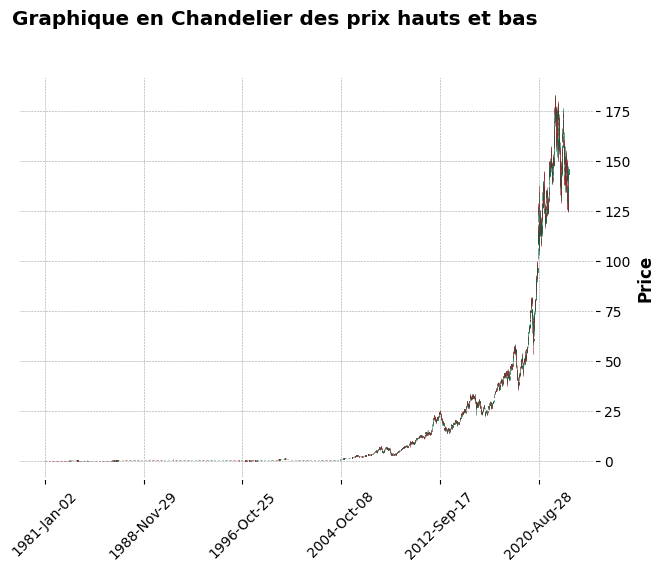

In [ ]:
# je vais maintenant regarder les deux courbes fusionnée 
# je dois aussi créer un graphique en chandelier en utilisant mpfinance 
import mplfinance as mpf  # Bibliothèque spécialisée recommandée pour les chandeliers
plt.title("courbe d'ouverture et de fermetture de l'action Apple  au cours du temps ")
sns.lineplot(data=data_chunk, x='Date',y='Open',label='heure d\'ouverture')
sns.lineplot(data=data_chunk, x='Date',y='Close',label='heure de cloture', color='orange')

plt.show()
# je vais faire une fonction pour pouvoir afficher des chandelier pour un dataframe en particulier sans avoir à reecrire tout mon code 

def Show_chandelier_plot(data):
    try:

        if data.index.name != "Date": # verifier si les index sont des dates au lieu de chiffre ( 0, 1, 2 ) si c'est des chiffre , on transformera les dates en index et on affichera donc le plot 

            data = data.set_index("Date")
            print("Date column converted to index")

        mpf.plot(
            data,
            type='candle',
            style='charles',
            title="Graphique en Chandelier des prix hauts et bas"
        )

    except Exception as e:

        print(f"An error occurred : {e}")
#on constate que les deux courbes se confondent en plusieurs points et qu'il ya de subrtiles différences au niveau des heures d'ouvertures 

Show_chandelier_plot(stocks_data)

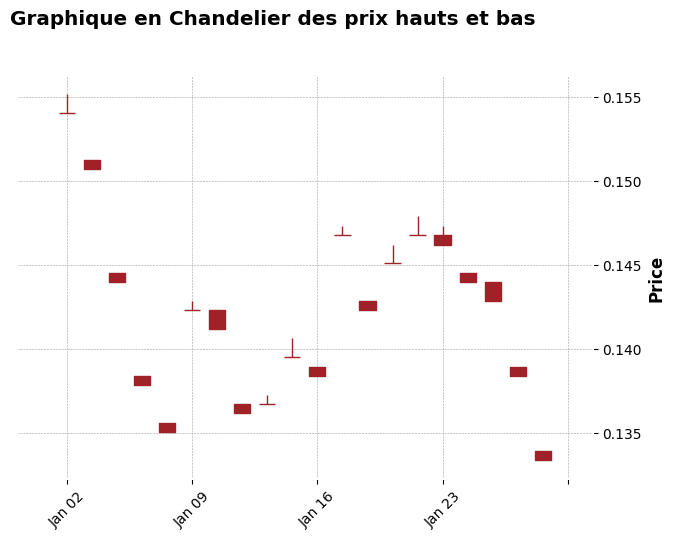

In [ ]:
#Je vais reduire le chunk de donnée pour poouvoir voir les chandelier 
# je vais faire une fonction pour pouvoir afficher des chandelier pour un dataframe en particulier sans avoir à reecrire tout mon code 

data_chunk=stocks_data.head(20)
Show_chandelier_plot(data_chunk)

T-test entre 1981 et 1982
t-statistic: 10.579143129232206
p-value: 1.153054877547318e-23
difference significative entre les moyennes
Date
1981-01-02         NaN
1981-01-05   -0.021738
1981-01-06   -0.044448
1981-01-07   -0.042633
1981-01-08   -0.020242
Name: Daily_Return, dtype: float64


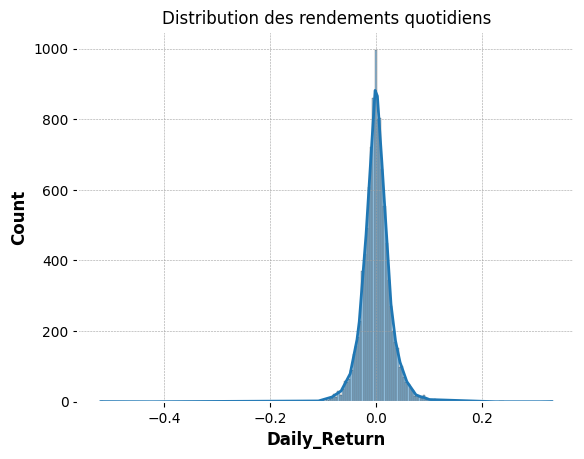

Test de normalité (Shapiro-Wilk)
statistic: 0.929036310325436
p-value: 1.2046884764219627e-14
les rendements ne suivent pas une loi normale


In [ ]:
import numpy as np
from scipy import stats

#je crèe une nouvelle colonne : 
stocks_data["Year"] = stocks_data.index.year

#Test T : comparaison des moyennes de cloture entre 2 années 

def test_T(year1,year2):
    close_year1 = stocks_data[stocks_data["Year"] == year1]["Close"]    
    close_year2 = stocks_data[stocks_data["Year"] == year2]["Close"]
    t_stat, p_value = stats.ttest_ind(close_year1, close_year2, equal_var=False)

    print(f"T-test entre {year1} et {year2}")
    print(f"t-statistic: {t_stat}")
    print(f"p-value: {p_value}")

    if p_value < 0.05:
        print("difference significative entre les moyennes")
    else:
        print("pas de difference significative")

test_T(1981,1982)

#Verification des rendements QUOTIDIENS 
#JE CREE LA NOUVELLE VARIABLE RETURN / Retour sur investissement 
stocks_data["Daily_Return"] = stocks_data["Close"].pct_change()
print(stocks_data["Daily_Return"].head())
# enlever les NaN du premier jour
returns = stocks_data["Daily_Return"].dropna()



#On visualise la distribution  des rendements quotidien afin de s'assurer visuelemnet de leur normalité 
plt.figure()
sns.histplot(returns, kde=True)
plt.title("Distribution des rendements quotidiens")
plt.show()


#On test la normalité 

stat, p_value = stats.shapiro(returns.sample(500) if len(returns) > 500 else returns)

print("Test de normalité (Shapiro-Wilk)")
print(f"statistic: {stat}")
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("les rendements ne suivent pas une loi normale")
else:
    print("les rendements suivent approximativement une loi normale")






RAPPORT D'ANALYSE 

